## Notebook 01 — Data Exploration
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** Initial dataset exploration. Class distribution and sample images


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [2]:
DATASET_PATH = os.path.join('..', 'datasets','dataset-resized')
CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
print("Dataset Path: ",DATASET_PATH)
print("Classes: ", CLASSES)

Dataset Path:  ..\datasets\dataset-resized
Classes:  ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']


In [3]:
# Traverses each class folder to collect image file paths with their corresponding class labels

image_paths = []
labels = []

for class_name in CLASSES:
    class_folder = os.path.join(DATASET_PATH, class_name)
    for filename in os.listdir(class_folder):
        if filename.endswith('.jpg'):
            image_paths.append(os.path.join(class_folder, filename))
            labels.append(class_name)

print(f"Total images loaded: {len(image_paths)}")
print(f"Total labels loaded: {len(labels)}")

Total images loaded: 2527
Total labels loaded: 2527


In [4]:
class_counts = Counter(labels)

print("Images per class: ")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Images per class: 
glass: 501
paper: 594
cardboard: 403
plastic: 482
metal: 410
trash: 137


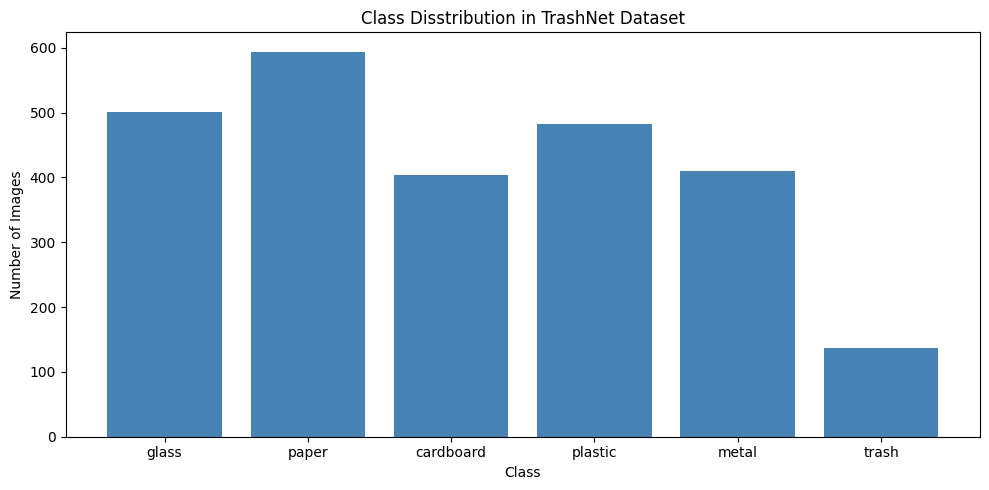

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Class Disstribution in TrashNet Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

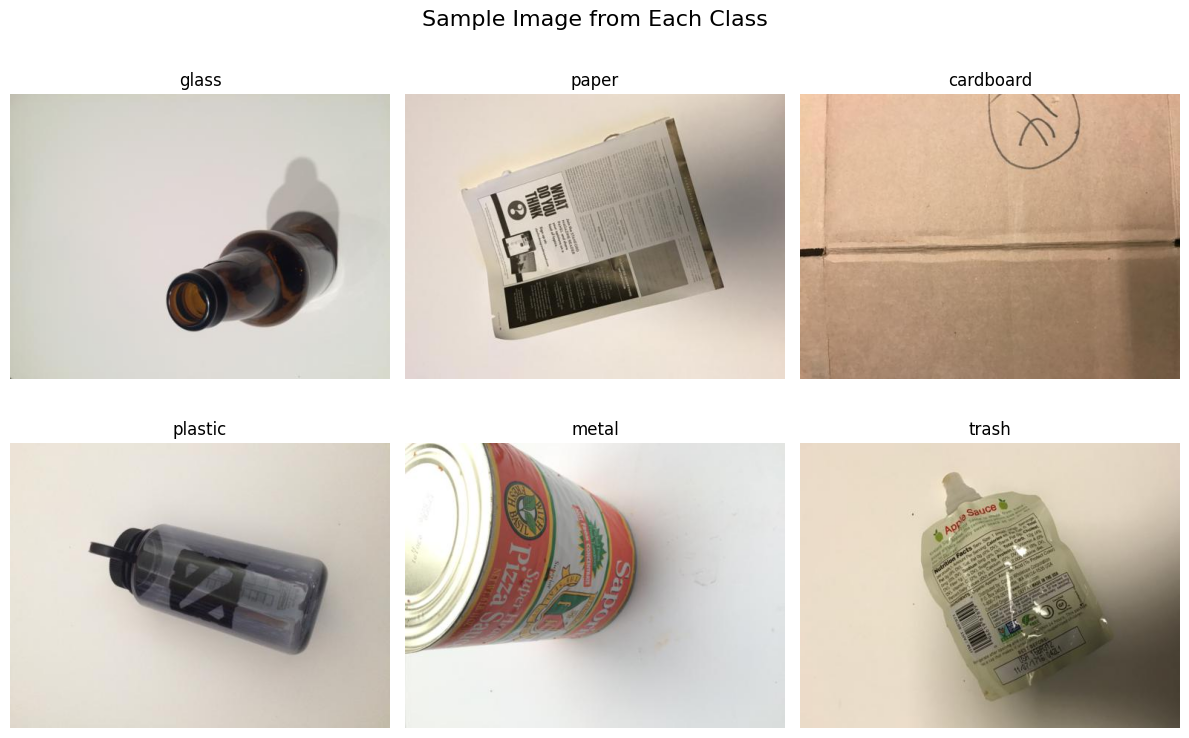

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, class_name in enumerate(CLASSES):
    class_folder = os.path.join(DATASET_PATH, class_name)
    sample_image_path = os.path.join(class_folder, os.listdir(class_folder)[0])
    img = Image.open(sample_image_path)

    axes[idx].imshow(img)
    axes[idx].set_title(class_name)
    axes[idx].axis('off')

plt.suptitle('Sample Image from Each Class', fontsize=16)
plt.tight_layout()
plt.savefig('../results/figures/sample_images.png', dpi=150)
plt.show()